<a href="https://colab.research.google.com/github/kimshy22/SOH_NASA/blob/main/nasa_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import os
import json
import math
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [3]:

from google.colab import drive
drive.mount('/content/drive')

csv_path = "/content/drive/MyDrive/NASA_DATA_SCRIPTS/NASA_Combined_cycle_level.csv"
print("Using file:", csv_path)

Mounted at /content/drive
Using file: /content/drive/MyDrive/NASA_DATA_SCRIPTS/NASA_Combined_cycle_level.csv


In [4]:

df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nHead:")
display(df.head())

Shape: (636, 31)

Columns:
['battery_id', 'cycle_id', 'config_name', 'event_id', 'event_type', 'valid_for_direct_soh', 'row_mode', 'measured_capacity_ah', 'corrected_capacity_ah', 'estimated_full_capacity_ah', 'reference_capacity_ah', 'soh_percent', 'soh_percent_smoothed', 'soh_status', 'duration_s', 'num_rows', 'start_time_s', 'end_time_s', 'start_voltage_v', 'end_voltage_v', 'min_voltage_v', 'max_voltage_v', 'voltage_drop_v', 'avg_discharge_current_a', 'avg_charge_current_a', 'avg_temperature_c', 'soc_start', 'soc_end', 'soc_window', 'needs_soc_window_correction', 'notes']

Head:


,battery_id,cycle_id,config_name,event_id,event_type,valid_for_direct_soh,row_mode,measured_capacity_ah,corrected_capacity_ah,estimated_full_capacity_ah,...,max_voltage_v,voltage_drop_v,avg_discharge_current_a,avg_charge_current_a,avg_temperature_c,soc_start,soc_end,soc_window,needs_soc_window_correction,notes
0,B0005,2,nasa_b0005,2,full_discharge,True,discharge,1.861758,1.861758,1.861758,...,3.974871,1.362404,2.012621,0.0,32.285161,NaN,NaN,NaN,False,Looks like a full discharge event.
1,B0005,4,nasa_b0005,5,full_discharge,True,discharge,1.851638,1.851638,1.851638,...,3.979157,1.391948,2.012561,0.0,32.438327,NaN,NaN,NaN,False,Looks like a full discharge event.
2,B0005,6,nasa_b0005,8,full_discharge,True,discharge,1.840640,1.840640,1.840640,...,3.979995,1.328078,2.012474,0.0,32.363279,NaN,NaN,NaN,False,Looks like a full discharge event.
3,B0005,8,nasa_b0005,11,full_discharge,True,discharge,1.840558,1.840558,1.840558,...,3.981613,1.388665,2.012181,0.0,32.236975,NaN,NaN,NaN,False,Looks like a full discharge event.
4,B0005,10,nasa_b0005,14,full_discharge,True,discharge,1.839931,1.839931,1.839931,...,3.982253,1.434834,2.012707,0.0,32.099754,NaN,NaN,NaN,False,Looks like a full discharge event.


In [5]:

allowed_batteries = ["B0005", "B0006", "B0007", "B0018"]

# Keep only required batteries
df = df[df["battery_id"].isin(allowed_batteries)].copy()

# Keep only valid discharge cycles if those columns exist
if "event_type" in df.columns:
    df = df[df["event_type"].astype(str).str.lower().str.contains("discharge", na=False)]

# If there is a validity flag column, use it
possible_valid_cols = ["is_valid", "valid", "validity_flag", "valid_cycle"]
for col in possible_valid_cols:
    if col in df.columns:
        df = df[df[col] == True].copy()
        print(f"Applied validity filter using: {col}")
        break

# Remove rows with missing key target/features
required_cols = [
    "battery_id",
    "cycle_id",
    "corrected_capacity_ah",
    "duration_s",
    "avg_discharge_current_a",
    "avg_temperature_c",
    "start_voltage_v",
    "end_voltage_v",
    "soh_percent_smoothed"
]

df = df.dropna(subset=required_cols).copy()

# Sort properly
df = df.sort_values(["battery_id", "cycle_id"]).reset_index(drop=True)

print("Filtered shape:", df.shape)
display(df.head())

Filtered shape: (636, 31)


,battery_id,cycle_id,config_name,event_id,event_type,valid_for_direct_soh,row_mode,measured_capacity_ah,corrected_capacity_ah,estimated_full_capacity_ah,...,max_voltage_v,voltage_drop_v,avg_discharge_current_a,avg_charge_current_a,avg_temperature_c,soc_start,soc_end,soc_window,needs_soc_window_correction,notes
0,B0005,2,nasa_b0005,2,full_discharge,True,discharge,1.861758,1.861758,1.861758,...,3.974871,1.362404,2.012621,0.0,32.285161,NaN,NaN,NaN,False,Looks like a full discharge event.
1,B0005,4,nasa_b0005,5,full_discharge,True,discharge,1.851638,1.851638,1.851638,...,3.979157,1.391948,2.012561,0.0,32.438327,NaN,NaN,NaN,False,Looks like a full discharge event.
2,B0005,6,nasa_b0005,8,full_discharge,True,discharge,1.840640,1.840640,1.840640,...,3.979995,1.328078,2.012474,0.0,32.363279,NaN,NaN,NaN,False,Looks like a full discharge event.
3,B0005,8,nasa_b0005,11,full_discharge,True,discharge,1.840558,1.840558,1.840558,...,3.981613,1.388665,2.012181,0.0,32.236975,NaN,NaN,NaN,False,Looks like a full discharge event.
4,B0005,10,nasa_b0005,14,full_discharge,True,discharge,1.839931,1.839931,1.839931,...,3.982253,1.434834,2.012707,0.0,32.099754,NaN,NaN,NaN,False,Looks like a full discharge event.


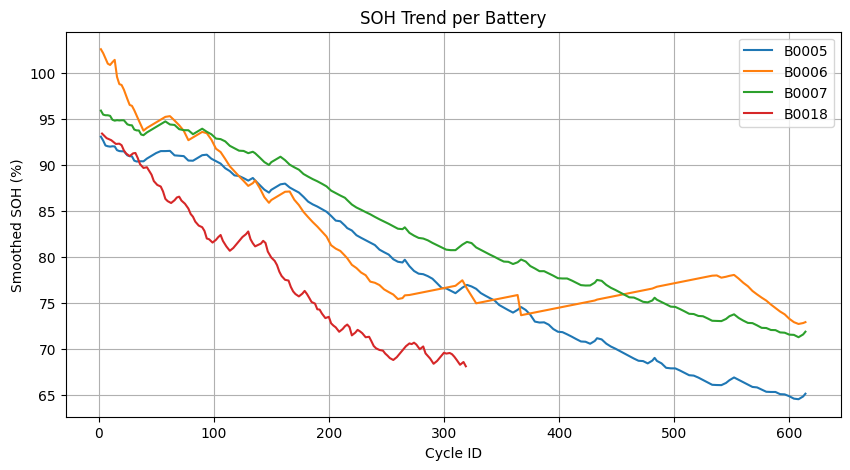

In [6]:

plt.figure(figsize=(10, 5))

for bid in allowed_batteries:
    temp = df[df["battery_id"] == bid]
    if len(temp) > 0:
        plt.plot(temp["cycle_id"], temp["soh_percent_smoothed"], label=bid)

plt.xlabel("Cycle ID")
plt.ylabel("Smoothed SOH (%)")
plt.title("SOH Trend per Battery")
plt.legend()
plt.grid(True)
plt.show()

In [7]:

feature_cols = [
    "cycle_id",
    "corrected_capacity_ah",
    "duration_s",
    "avg_discharge_current_a",
    "avg_temperature_c",
    "start_voltage_v",
    "end_voltage_v"
]

target_col = "soh_percent_smoothed"

print("Features:", feature_cols)
print("Target:", target_col)

Features: ['cycle_id', 'corrected_capacity_ah', 'duration_s', 'avg_discharge_current_a', 'avg_temperature_c', 'start_voltage_v', 'end_voltage_v']
Target: soh_percent_smoothed


In [8]:

train_batteries = ["B0005", "B0006"]
val_batteries   = ["B0007"]
test_batteries  = ["B0018"]

train_df = df[df["battery_id"].isin(train_batteries)].copy()
val_df   = df[df["battery_id"].isin(val_batteries)].copy()
test_df  = df[df["battery_id"].isin(test_batteries)].copy()

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (336, 31)
Val shape: (168, 31)
Test shape: (132, 31)


In [9]:

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# Fit on train only
feature_scaler.fit(train_df[feature_cols])
target_scaler.fit(train_df[[target_col]])

# Transform each split
train_df_scaled = train_df.copy()
val_df_scaled   = val_df.copy()
test_df_scaled  = test_df.copy()

train_df_scaled[feature_cols] = feature_scaler.transform(train_df[feature_cols])
val_df_scaled[feature_cols]   = feature_scaler.transform(val_df[feature_cols])
test_df_scaled[feature_cols]  = feature_scaler.transform(test_df[feature_cols])

train_df_scaled[[target_col]] = target_scaler.transform(train_df[[target_col]])
val_df_scaled[[target_col]]   = target_scaler.transform(val_df[[target_col]])
test_df_scaled[[target_col]]  = target_scaler.transform(test_df[[target_col]])

print("Scaling complete.")

Scaling complete.


In [10]:

def build_sequences_per_battery(dataframe, feature_cols, target_col, window_size=10, horizon=1):
    """
    Builds sequences separately for each battery.

    Input shape per sample:  (window_size, num_features)
    Target: SOH at future cycle = current_end + horizon
    """
    X, y = [], []
    meta = []

    for battery_id in dataframe["battery_id"].unique():
        temp = dataframe[dataframe["battery_id"] == battery_id].sort_values("cycle_id").reset_index(drop=True)

        feature_array = temp[feature_cols].values
        target_array = temp[target_col].values
        cycle_ids = temp["cycle_id"].values

        max_start = len(temp) - window_size - horizon + 1

        if max_start <= 0:
            print(f"Skipping {battery_id}: not enough cycles for window={window_size}, horizon={horizon}")
            continue

        for i in range(max_start):
            x_seq = feature_array[i:i + window_size]
            y_target = target_array[i + window_size + horizon - 1]

            X.append(x_seq)
            y.append(y_target)

            meta.append({
                "battery_id": battery_id,
                "input_start_cycle": int(cycle_ids[i]),
                "input_end_cycle": int(cycle_ids[i + window_size - 1]),
                "target_cycle": int(cycle_ids[i + window_size + horizon - 1])
            })

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32).reshape(-1, 1)

    return X, y, pd.DataFrame(meta)

In [11]:

WINDOW_SIZE = 10
HORIZON = 1   # next-cycle prediction

X_train, y_train, meta_train = build_sequences_per_battery(
    train_df_scaled, feature_cols, target_col, window_size=WINDOW_SIZE, horizon=HORIZON
)

X_val, y_val, meta_val = build_sequences_per_battery(
    val_df_scaled, feature_cols, target_col, window_size=WINDOW_SIZE, horizon=HORIZON
)

X_test, y_test, meta_test = build_sequences_per_battery(
    test_df_scaled, feature_cols, target_col, window_size=WINDOW_SIZE, horizon=HORIZON
)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

display(meta_train.head())

X_train: (316, 10, 7) y_train: (316, 1)
X_val: (158, 10, 7) y_val: (158, 1)
X_test: (122, 10, 7) y_test: (122, 1)


,battery_id,input_start_cycle,input_end_cycle,target_cycle
0,B0005,0,0,0
1,B0005,0,0,0
2,B0005,0,0,0
3,B0005,0,0,0
4,B0005,0,0,0


In [12]:

def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(32, input_shape=input_shape, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )
    return model

model = build_lstm_model((X_train.shape[1], X_train.shape[2]))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,665 (22.13 KB)

 Trainable params: 5,665 (22.13 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath="best_lstm_model.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.0881 - mae: 0.2326 - val_loss: 0.6570 - val_mae: 0.7888
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0247 - mae: 0.1257 - val_loss: 0.5963 - val_mae: 0.7518
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0107 - mae: 0.0832 - val_loss: 0.5650 - val_mae: 0.7316
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0094 - mae: 0.0796 - val_loss: 0.5729 - val_mae: 0.7363
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0087 - mae: 0.0756 - val_loss: 0.5588 - val_mae: 0.7258
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0068 - mae: 0.0670 - val_loss: 0.5345 - val_mae: 0.7088
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0064 - mae: 0.0646 - val_loss: 0.5176 - val_mae: 0.6959
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0054 - mae: 0.0599 - val_loss: 0.4970 - val_mae: 0.6805
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - los

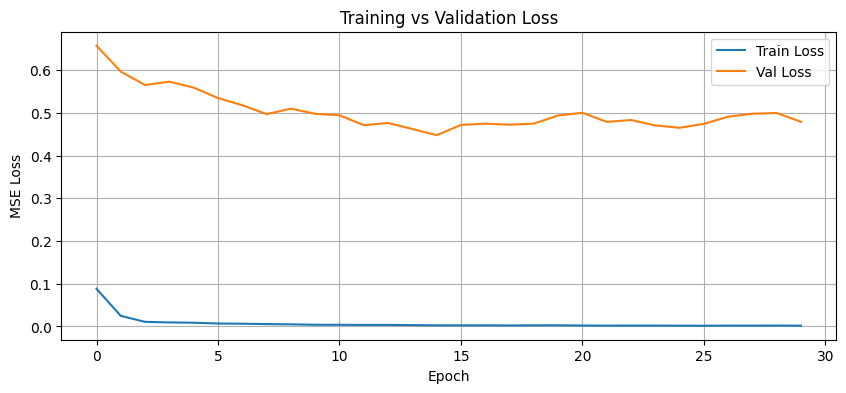

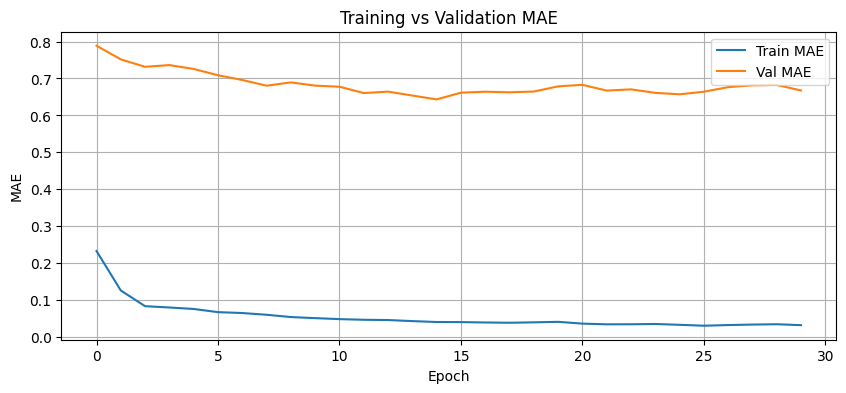

In [14]:

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Val MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")
plt.legend()
plt.grid(True)
plt.show()

In [15]:

y_pred_scaled = model.predict(X_test)

# Inverse transform target back to real SOH scale
y_test_real = target_scaler.inverse_transform(y_test)
y_pred_real = target_scaler.inverse_transform(y_pred_scaled)

mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)

print(f"Test MAE  : {mae:.4f}")
print(f"Test RMSE : {rmse:.4f}")
print(f"Test R^2  : {r2:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Test MAE  : 2.9486
Test RMSE : 3.0824
Test R^2  : 0.7955


,battery_id,input_start_cycle,input_end_cycle,target_cycle,actual_soh,predicted_soh,abs_error
0,B0018,0,0,0,91.313644,91.449974,0.136330
1,B0018,0,0,0,90.765556,91.536209,0.770653
2,B0018,0,0,0,90.096138,91.420090,1.323952
3,B0018,0,0,0,89.685555,91.019196,1.333641
4,B0018,0,0,0,89.761635,90.545761,0.784126


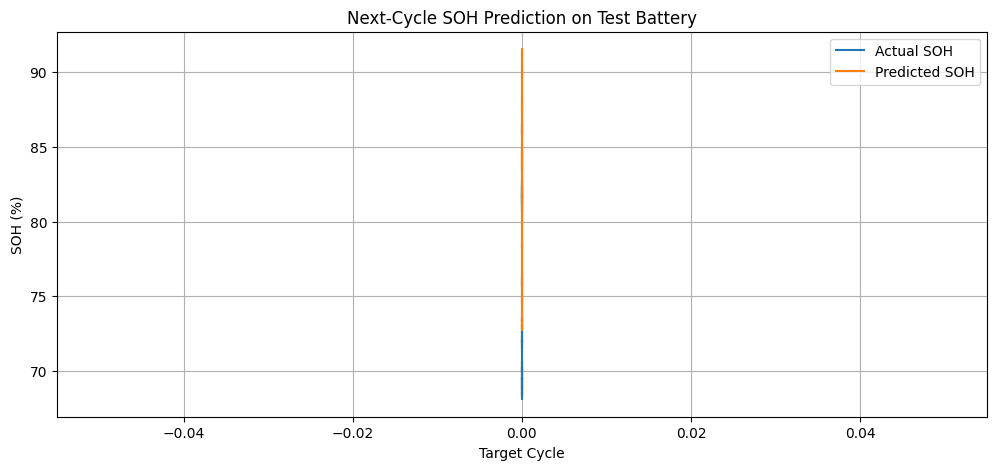

In [16]:

results_df = meta_test.copy()
results_df["actual_soh"] = y_test_real.flatten()
results_df["predicted_soh"] = y_pred_real.flatten()
results_df["abs_error"] = np.abs(results_df["actual_soh"] - results_df["predicted_soh"])

display(results_df.head())

plt.figure(figsize=(12, 5))
plt.plot(results_df["target_cycle"], results_df["actual_soh"], label="Actual SOH")
plt.plot(results_df["target_cycle"], results_df["predicted_soh"], label="Predicted SOH")
plt.xlabel("Target Cycle")
plt.ylabel("SOH (%)")
plt.title("Next-Cycle SOH Prediction on Test Battery")
plt.legend()
plt.grid(True)
plt.show()

In [17]:

model.save("lstm_soh_predictor.keras")
joblib.dump(feature_scaler, "feature_scaler.gz")
joblib.dump(target_scaler, "target_scaler.gz")

config = {
    "feature_cols": feature_cols,
    "target_col": target_col,
    "window_size": WINDOW_SIZE,
    "horizon": HORIZON,
    "train_batteries": train_batteries,
    "val_batteries": val_batteries,
    "test_batteries": test_batteries,
    "model_type": "Compact LSTM for cycle-level SOH prognosis",
    "chemistry": "LCO",
    "dataset": "NASA Ames Prognostics Center Battery Dataset"
}

with open("training_config.json", "w") as f:
    json.dump(config, f, indent=4)

print("Saved:")
print("- lstm_soh_predictor.keras")
print("- feature_scaler.gz")
print("- target_scaler.gz")
print("- training_config.json")

Saved:
- lstm_soh_predictor.keras
- feature_scaler.gz
- target_scaler.gz
- training_config.json


In [19]:
import os

SAVE_DIR = "/content/drive/MyDrive/NASA_DATA_SCRIPTS/lstm_v1"

os.makedirs(SAVE_DIR, exist_ok=True)

print("Saving to:", SAVE_DIR)

Saving to: /content/drive/MyDrive/NASA_DATA_SCRIPTS/lstm_v1


In [20]:
import shutil

files_to_save = [
    "lstm_soh_predictor.keras",
    "feature_scaler.gz",
    "target_scaler.gz",
    "training_config.json",
    "best_lstm_model.keras",
    "lstm_soh_predictor.tflite"  # optional (if exists)
]

for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, SAVE_DIR)
        print(f"Saved: {f}")
    else:
        print(f"Skipped (not found): {f}")

Saved: lstm_soh_predictor.keras
Saved: feature_scaler.gz
Saved: target_scaler.gz
Saved: training_config.json
Saved: best_lstm_model.keras
Skipped (not found): lstm_soh_predictor.tflite


In [21]:
joblib.dump(feature_scaler, "feature_scaler.gz")
joblib.dump(target_scaler, "target_scaler.gz")

['target_scaler.gz']

In [23]:

#  TFLite conversion

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
converter._experimental_lower_tensor_list_ops = False
tflite_model = converter.convert()

with open("lstm_soh_predictor.tflite", "wb") as f:
    f.write(tflite_model)

print("Saved: lstm_soh_predictor.tflite")

Saved artifact at '/tmp/tmpj2zfmmfn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10, 7), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135305030994448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135305030994832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135305030995984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135305030996368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135305030993104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135305030994640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135305030996560: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved: lstm_soh_predictor.tflite


In [24]:
import shutil

files_to_save = [

    "lstm_soh_predictor.tflite"  # optional (if exists)
]

for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, SAVE_DIR)
        print(f"Saved: {f}")
    else:
        print(f"Skipped (not found): {f}")

Saved: lstm_soh_predictor.tflite
